In [1]:
import json
import re
from pathlib import Path

def transition_to_filename(transition, suffix=""):
    if not isinstance(transition, str):
        transition = str(transition)
    safe = re.sub(r"[^\d\-\[\],]+", "_", transition).strip("_")
    safe = safe.replace("[", "(").replace("]", ")")
    return f"{safe}{suffix}.txt"

def load_arrays_for_transition(saved_dir, transition):
    saved_dir = Path(saved_dir)
    filename = transition_to_filename(transition)
    path = saved_dir / filename

    if not path.exists():
        raise FileNotFoundError(f"No saved file for transition {transition}. Expected: {path}")

    data = json.loads(path.read_text(encoding="utf-8"))

    exp_wait_times = data["exp_wait_times_us"]
    exp_phases_pm1 = data["exp_phases_pm1"]

    return exp_wait_times, exp_phases_pm1, path

# ---- example usage ----
saved_dir = "Uncompensated_Phase_Data"
saved_dir = "Compensated_Phase_Data"
transition = "[[0, 4, 1], [0, 2, 0]]"  # can also pass eval(...) list

exp_wait_times, exp_phases_pm1, file_path = load_arrays_for_transition(saved_dir, transition)

print("Loaded from:", file_path)
print("exp_wait_times length:", len(exp_wait_times))
print("exp_phases_pm1 length:", len(exp_phases_pm1))

Loaded from: Compensated_Phase_Data\((0,_4,_1),_(0,_2,_0)).txt
exp_wait_times length: 69
exp_phases_pm1 length: 69


In [2]:
import re
from pathlib import Path

# Matches a transition like: [[0, 3, -1], [0, 2, 0]]
TRANSITION_RE = re.compile(r'(\[\[\s*-?\d+\s*,\s*-?\d+\s*,\s*-?\d+\s*\]\s*,\s*\[\s*-?\d+\s*,\s*-?\d+\s*,\s*-?\d+\s*\]\s*\])')

# Matches datetime strings like: 20260220_1446
DT_RE = re.compile(r'\b\d{8}_\d{4}\b')

def transitions_with_datetimes(filepath: str):
    text = Path(filepath).read_text(encoding="utf-8", errors="replace")

    results = []  # each item: {"transition": "...", "datetimes": [...], "line": <int>}
    for lineno, line in enumerate(text.splitlines(), start=1):
        m = TRANSITION_RE.search(line)
        if not m:
            continue

        transition_str = m.group(1)
        datetimes = DT_RE.findall(line)

        if datetimes:
            results.append(
                {
                    "transition": transition_str,
                    "datetimes": sorted(set(datetimes)),
                    "line": lineno,
                }
            )

    # If you only want unique transitions (not repeated across lines), dedupe here:
    unique = {}
    for r in results:
        key = r["transition"]
        unique.setdefault(key, set()).update(r["datetimes"])
    unique_list = [{"transition": k, "datetimes": sorted(v)} for k, v in unique.items()]

    return unique_list, results

path = "Bussed_Ramsey_datetime_log.txt"

unique_list, per_line = transitions_with_datetimes(path)

print("Transitions that have datetimes associated with them:")
for item in unique_list:
    print(eval(item["transition"]))

Transitions that have datetimes associated with them:
[[0, 3, -1], [0, 2, 0]]
[[0, 3, 0], [0, 2, 0]]
[[0, 3, 1], [0, 2, 0]]
[[0, 3, 2], [0, 2, 0]]
[[0, 4, -2], [0, 2, 0]]
[[0, 4, -1], [0, 2, 0]]
[[0, 4, 0], [0, 2, 0]]
[[0, 4, 1], [0, 2, 0]]


In [3]:
print(exp_phases_pm1)
print(exp_wait_times)

[-0.055065040786160147, 0.014158917290661766, 0.023979083338129037, -0.020000000000000462, -0.02486902749029518, -0.03954838306223696, -0.020000000000000462, -0.03729685505662328, -0.07044794164151558, -0.033475312897913945, 0.006052407617162636, -0.08734800278865062, -0.06163080952054667, -0.06290329806321981, 0.05032712793967553, -0.024829058963105943, -0.020000000000000462, -0.06983097669663563, -0.056710366337124896, -0.19783656205406297, 0.02449468488504869, -0.11785405075747235, 0.030180045279958545, -0.12269563533395944, -0.035036351239987606, 0.03995135150516771, -0.09374148189294029, -0.1016594333022085, 0.11463664067962842, 0.08647295382463316, 0.08318542282043939, 0.3014567557895851, 0.1752867743148161, 0.13926844117770254, 0.156866559043233, -0.041483498940925845, 0.2764702600671627, 0.438739342553613, 0.1534110189282032, 0.11119573312216136, 0.19599233376273117, -0.04273781401341736, 0.20963088564700572, -0.02638995763835883, -0.020000000000000462, -0.07589514919709384, 0.

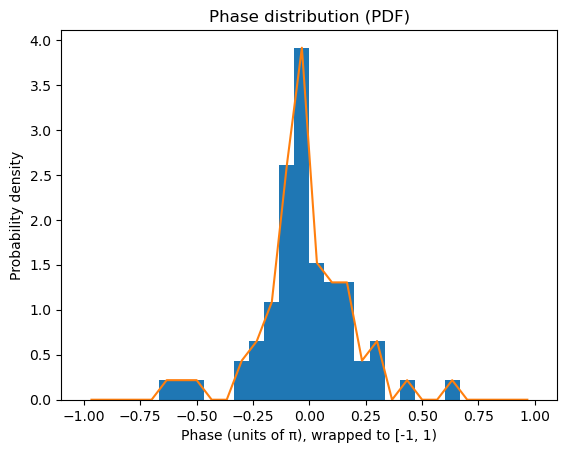

In [4]:
import numpy as np
import matplotlib.pyplot as plt

phases = np.asarray(exp_phases_pm1, dtype=float)
phase_range = (-1, 1)
bins = 30

counts, edges = np.histogram(phases, bins=bins, range=phase_range, density=False)
bin_widths = np.diff(edges)
pdf = counts / (counts.sum() * bin_widths)   # integrates to ~1 over range
centers = (edges[:-1] + edges[1:]) / 2

plt.figure()
plt.hist(phases, bins=bins, range=phase_range, density=True)
# plt.xlabel("Phase (units of π), wrapped to [-1, 1)")
# plt.ylabel("Probability density" if density else "Count")
# plt.title("Phase histogram")
# plt.show()

# optional plot
import matplotlib.pyplot as plt
# plt.figure()
plt.plot(centers, pdf)
plt.xlabel("Phase (units of π), wrapped to [-1, 1)")
plt.ylabel("Probability density")
plt.title("Phase distribution (PDF)")
plt.show()

In [5]:
def get_pi_times_from_matrix(transitions, matrix):
    Fs = [1, 2, 3, 4]
    states = []
    for i in Fs:
        for j in range(2 * i + 1):
            mF = i - j
            states.append([i, mF])
    row_labels = states
    col_labels = [-2, -1, 0, 1, 2]

    out = []
    for transition in transitions:
        row_label = [transition[1], transition[2]]
        col_label = transition[0]
        row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
        col_index = col_labels.index(col_label) if col_label in col_labels else None
        if row_index is not None and col_index is not None:
            out.append(matrix[row_index, col_index])
        else:
            out.append(np.nan)
    return out

sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p2079.txt"
sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")


sens_list: [np.float64(-1.3868685343823017), np.float64(4.0589839045424014e-05)]


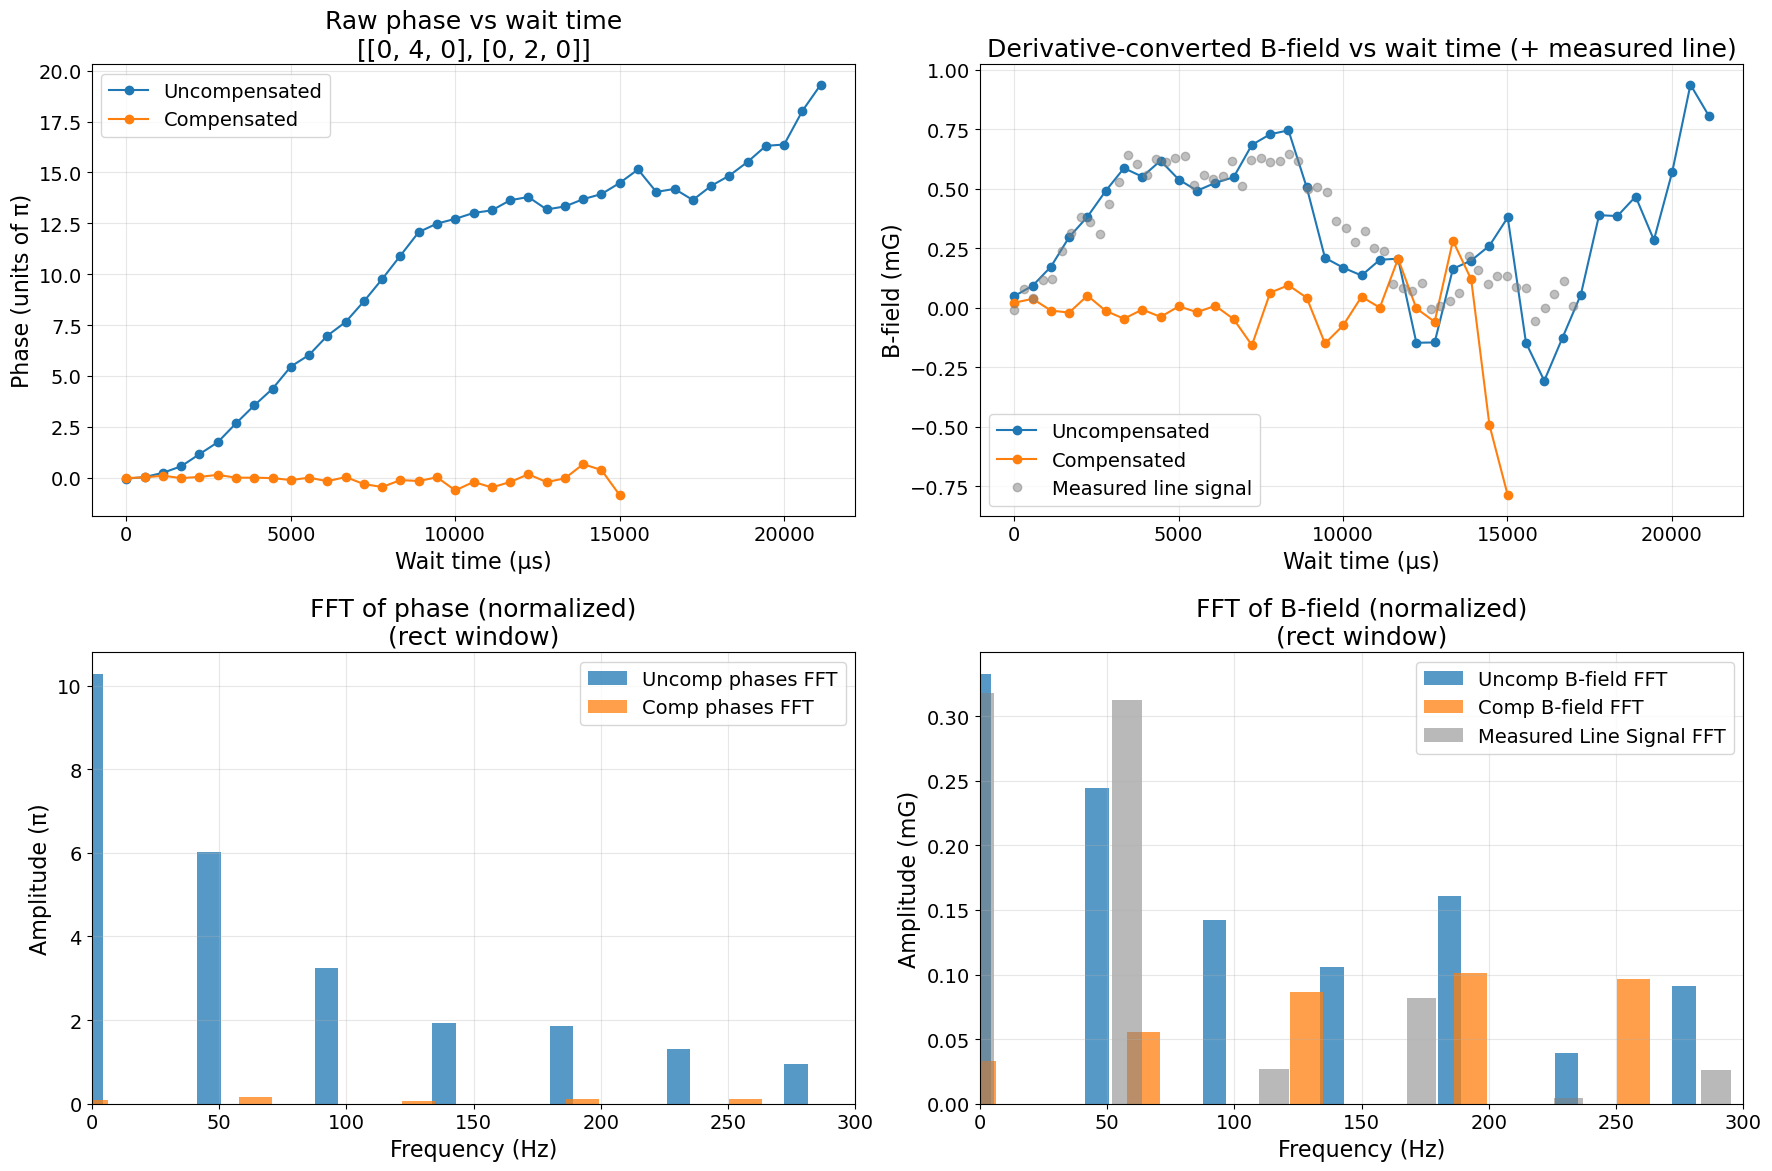

Loaded uncomp: Uncompensated_Phase_Data\((0,_4,_0),_(0,_2,_0)).txt
Loaded comp  : Compensated_Phase_Data\((0,_4,_0),_(0,_2,_0)).txt
Uncomp dt (s): 0.0005559999999999983   N: 39
Comp   dt (s): 0.0005559999999999992   N: 28
Line signal file: LineSignal_Data/line_signal_pm_new.json
Line dt (s): 0.0002881355932203393   N: 60


In [10]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ----------------- loading helpers -----------------
def transition_to_filename(transition, suffix=""):
    if not isinstance(transition, str):
        transition = str(transition)
    safe = re.sub(r"[^\d\-\[\],]+", "_", transition).strip("_")
    safe = safe.replace("[", "(").replace("]", ")")
    return f"{safe}{suffix}.txt"


def load_arrays_for_transition(saved_dir, transition):
    saved_dir = Path(saved_dir)
    filename = transition_to_filename(transition)
    path = saved_dir / filename
    if not path.exists():
        raise FileNotFoundError(f"No saved file for transition {transition}. Expected: {path}")

    data = json.loads(path.read_text(encoding="utf-8"))
    return data["exp_wait_times_us"], data["exp_phases_pm1"], path


def load_line_signal_file(line_signal_path):
    """
    Expects JSON with keys:
      - "fit_wait_times_us": list[float]
      - "B_mG": list[float]
    Returns (t_us, B_mG)
    """
    line_signal_path = Path(line_signal_path)
    if not line_signal_path.exists():
        raise FileNotFoundError(f"Line signal file not found: {line_signal_path}")
    data = json.loads(line_signal_path.read_text(encoding="utf-8"))
    return np.asarray(data["fit_wait_times_us"], float), np.asarray(data["B_mG"], float)


# ----------------- signal processing helpers -----------------
def combine_duplicate_times(t_us, y, method="mean"):
    t_us = np.asarray(t_us, dtype=float)
    y = np.asarray(y, dtype=float)

    idx = np.argsort(t_us)
    t_us = t_us[idx]
    y = y[idx]

    uniq_t, inv = np.unique(t_us, return_inverse=True)

    if method == "mean":
        y_out = np.zeros_like(uniq_t, dtype=float)
        counts = np.zeros_like(uniq_t, dtype=float)
        np.add.at(y_out, inv, y)
        np.add.at(counts, inv, 1.0)
        y_out = y_out / counts
    elif method == "median":
        y_out = np.zeros_like(uniq_t, dtype=float)
        for i in range(len(uniq_t)):
            y_out[i] = np.median(y[inv == i])
    else:
        raise ValueError("method must be 'mean' or 'median'")

    return uniq_t, y_out


def make_uniform_grid(t_us_unique, y_unique):
    """Interpolate onto a uniform grid using median dt (ignoring zero diffs)."""
    t_s = np.asarray(t_us_unique, dtype=float) * 1e-6

    diffs = np.diff(t_s)
    diffs = diffs[diffs > 0]
    if diffs.size == 0:
        raise ValueError("Not enough distinct time points to estimate dt.")
    dt = np.median(diffs)

    t_uniform = np.arange(t_s[0], t_s[-1] + dt / 2, dt)
    y_uniform = np.interp(t_uniform, t_s, y_unique)
    return t_uniform, y_uniform, dt


def amplitude_spectrum(y, dt, window="hann", remove_mean=True):
    """
    Single-sided amplitude spectrum with window correction.
    Returns freqs (Hz), amp (same units as y).
    """
    y = np.asarray(y, dtype=float)
    if remove_mean:
        y = y - 0*np.mean(y)

    N = len(y)
    if N < 2:
        raise ValueError("Need at least 2 samples for FFT.")

    if window is None:
        w = np.ones(N)
    elif window == "hann":
        w = np.hanning(N)
    else:
        raise ValueError("window must be None or 'hann'")

    yw = y * w
    Y = np.fft.rfft(yw)
    freqs = np.fft.rfftfreq(N, d=dt)

    cg = np.mean(w)  # coherent gain
    amp = (2.0 / N) * (np.abs(Y) / cg)

    # correct DC and Nyquist bins (not doubled)
    amp[0] *= 0.5
    if N % 2 == 0 and len(amp) > 1:
        amp[-1] *= 0.5

    return freqs, amp


# ----------------- main 2x2 comparison plot -----------------
def compare_comp_vs_uncomp_2x2(
    transition,
    uncomp_dir="Uncompensated_Phase_Data",
    comp_dir="Compensated_Phase_Data",
    combine_method="mean",
    fmax=300,                 # set None for full range
    window="hann",
    fig_size=(18, 12),
    font_size=16,
    # --- line signal overlay ---
    line_signal_path=None,    # e.g. "LineSignal_Data/line_signal_pm_new.json"
    line_signal_label="Line signal (measured)",
    line_signal_combine_method="mean",
):
    plt.rcParams.update({
        "font.size": font_size,
        "axes.titlesize": font_size + 2,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size - 2,
        "ytick.labelsize": font_size - 2,
        "legend.fontsize": font_size - 2,
    })

    # sens_matrix assumed defined in your notebook
    sens_list = get_pi_times_from_matrix(eval(transition), sens_matrix)
    print("sens_list:", sens_list)

    # Load main data
    t_u, y_u_raw, p_u = load_arrays_for_transition(uncomp_dir, transition)
    t_c, y_c_raw, p_c = load_arrays_for_transition(comp_dir, transition)

    # Combine duplicates
    t_u_u, y_u_u = combine_duplicate_times(t_u, y_u_raw, method=combine_method)
    t_c_u, y_c_u = combine_duplicate_times(t_c, y_c_raw, method=combine_method)

    # Uniform grids
    tu_s, yu_uniform, dt_u = make_uniform_grid(t_u_u, y_u_u)
    tc_s, yc_uniform, dt_c = make_uniform_grid(t_c_u, y_c_u)

    # Derivatives on uniform grids -> convert to B-field (mG)
    denom = (sens_list[1] - sens_list[0]) * 1e3
    dyu_dt_mG = (np.gradient(yu_uniform, dt_u) / 2.0) / denom
    dyc_dt_mG = (np.gradient(yc_uniform, dt_c) / 2.0) / denom

    # Spectra
    fu_p, Au_p = amplitude_spectrum(yu_uniform, dt_u, window=window, remove_mean=True)
    fc_p, Ac_p = amplitude_spectrum(yc_uniform, dt_c, window=window, remove_mean=True)

    fu_d, Au_d = amplitude_spectrum(dyu_dt_mG, dt_u, window=window, remove_mean=True)
    fc_d, Ac_d = amplitude_spectrum(dyc_dt_mG, dt_c, window=window, remove_mean=True)

    # --- optional line signal (already B in mG) ---
    have_line = line_signal_path is not None
    if have_line:
        t_ls_us, B_ls_mG = load_line_signal_file(line_signal_path)
        t_ls_u, B_ls_u = combine_duplicate_times(t_ls_us, B_ls_mG, method=line_signal_combine_method)
        tls_s, Bls_uniform, dt_ls = make_uniform_grid(t_ls_u, B_ls_u)

        f_ls, A_ls = amplitude_spectrum(Bls_uniform, dt_ls, window=window, remove_mean=True)

    def bar_width_from_freqs(f):
        return 0.2 * np.median(np.diff(f)) if len(f) > 1 else 1.0

    bw_fu_p, bw_fc_p = bar_width_from_freqs(fu_p), bar_width_from_freqs(fc_p)
    bw_fu_d, bw_fc_d = bar_width_from_freqs(fu_d), bar_width_from_freqs(fc_d)
    if have_line:
        bw_f_ls = bar_width_from_freqs(f_ls)

    # Plot 2x2 grid
    fig, ax = plt.subplots(2, 2, figsize=fig_size)
    ax_phase, ax_phase_fft = ax[0, 0], ax[1, 0]
    ax_deriv, ax_deriv_fft = ax[0, 1], ax[1, 1]

    # --- Top-left: raw phase ---
    line_u_phase = ax_phase.plot(t_u_u, y_u_u, marker="o", linestyle="-", label="Uncompensated")[0]
    line_c_phase = ax_phase.plot(t_c_u, y_c_u, marker="o", linestyle="-", label="Compensated")[0]
    ax_phase.set_xlabel("Wait time (µs)")
    ax_phase.set_ylabel("Phase (units of π)")
    ax_phase.set_title(f"Raw phase vs wait time\n{transition}")
    ax_phase.grid(True, alpha=0.3)
    ax_phase.legend()

    # --- Top-right: derivative (B-field mG) ---
    line_u_der = ax_deriv.plot(tu_s * 1e6, dyu_dt_mG, marker="o", linestyle="-", label="Uncompensated")[0]
    line_c_der = ax_deriv.plot(tc_s * 1e6, dyc_dt_mG, marker="o", linestyle="-", label="Compensated")[0]

    if have_line:
        # overlay measured line B-field on same axis
        line_ls = ax_deriv.plot(tls_s * 1e6, Bls_uniform, 'o', color = 'gray', alpha=0.5, label=line_signal_label)[0]

    ax_deriv.set_xlabel("Wait time (µs)")
    ax_deriv.set_ylabel("B-field (mG)")
    ax_deriv.set_title("Derivative-converted B-field vs wait time (+ measured line)")
    ax_deriv.grid(True, alpha=0.3)
    ax_deriv.legend()

    # Match FFT colors to the time-domain phase lines
    u_color = line_u_phase.get_color()
    c_color = line_c_phase.get_color()

    # --- Bottom-left: FFT of phase ---
    ax_phase_fft.bar(fu_p, Au_p, width=bw_fu_p, alpha=0.75, align="center", color=u_color, label="Uncomp phases FFT")
    # ax_phase_fft.plot(fu_p, Au_p, linewidth=2, color=u_color, label="Uncomp |FFT(Phase)|")

    ax_phase_fft.bar(fc_p, Ac_p, width=bw_fc_p, alpha=0.75, align="center", color=c_color, label="Comp phases FFT")
    # ax_phase_fft.plot(fc_p, Ac_p, linewidth=2, color=c_color, label="Comp |FFT(Phase)|")

    ax_phase_fft.set_xlabel("Frequency (Hz)")
    ax_phase_fft.set_ylabel("Amplitude (π)")
    ax_phase_fft.set_title(f"FFT of phase (normalized)\n({window or 'rect'} window)")
    ax_phase_fft.grid(True, alpha=0.3)
    ax_phase_fft.legend(loc="best")
    if fmax is not None:
        ax_phase_fft.set_xlim(0, fmax)

    # --- Bottom-right: FFT of B-field (from derivative) + measured line FFT ---
    ax_deriv_fft.bar(fu_d, Au_d, width=bw_fu_d, alpha=0.75, align="center", color=u_color, label="Uncomp B-field FFT")
    # ax_deriv_fft.plot(fu_d, Au_d, linewidth=2, color=u_color, label="Uncomp |FFT(B)|")

    ax_deriv_fft.bar(fc_d, Ac_d, width=bw_fc_d, alpha=0.75, align="center", color=c_color, label="Comp B-field FFT")
    # ax_deriv_fft.plot(fc_d, Ac_d, linewidth=2, color=c_color, label="Comp |FFT(B)|")

    if have_line:
        # plot measured line spectrum in a neutral style
        ax_deriv_fft.bar(f_ls, A_ls, width=bw_f_ls, alpha=0.55, color = 'gray', align="center", label="Measured Line Signal FFT")
        # ax_deriv_fft.plot(f_ls, A_ls, linewidth=2, linestyle="--", label="Line |FFT(B)|")

    ax_deriv_fft.set_xlabel("Frequency (Hz)")
    ax_deriv_fft.set_ylabel("Amplitude (mG)")
    ax_deriv_fft.set_title(f"FFT of B-field (normalized)\n({window or 'rect'} window)")
    ax_deriv_fft.grid(True, alpha=0.3)
    ax_deriv_fft.legend(loc="best")
    if fmax is not None:
        ax_deriv_fft.set_xlim(0, fmax)

    plt.tight_layout()
    plt.show()

    print("Loaded uncomp:", p_u)
    print("Loaded comp  :", p_c)
    print("Uncomp dt (s):", dt_u, "  N:", len(yu_uniform))
    print("Comp   dt (s):", dt_c, "  N:", len(yc_uniform))
    if have_line:
        print("Line signal file:", line_signal_path)
        print("Line dt (s):", dt_ls, "  N:", len(Bls_uniform))


# ----------------- usage -----------------
transition = "[[0, 4, 0], [0, 2, 0]]"

compare_comp_vs_uncomp_2x2(
    transition=transition,
    uncomp_dir="Uncompensated_Phase_Data",
    comp_dir="Compensated_Phase_Data",
    combine_method="mean",
    fmax=300,          # None => no limit
    window=None,
    line_signal_path="LineSignal_Data/line_signal_pm_new.json",  
    line_signal_label="Measured line signal",
    line_signal_combine_method="mean",
)

Transitions that have datetimes associated with them:
[[0, 3, -1], [0, 2, 0]]
sens_list: [np.float64(-0.09705244110591593), np.float64(4.0589839045424014e-05)]


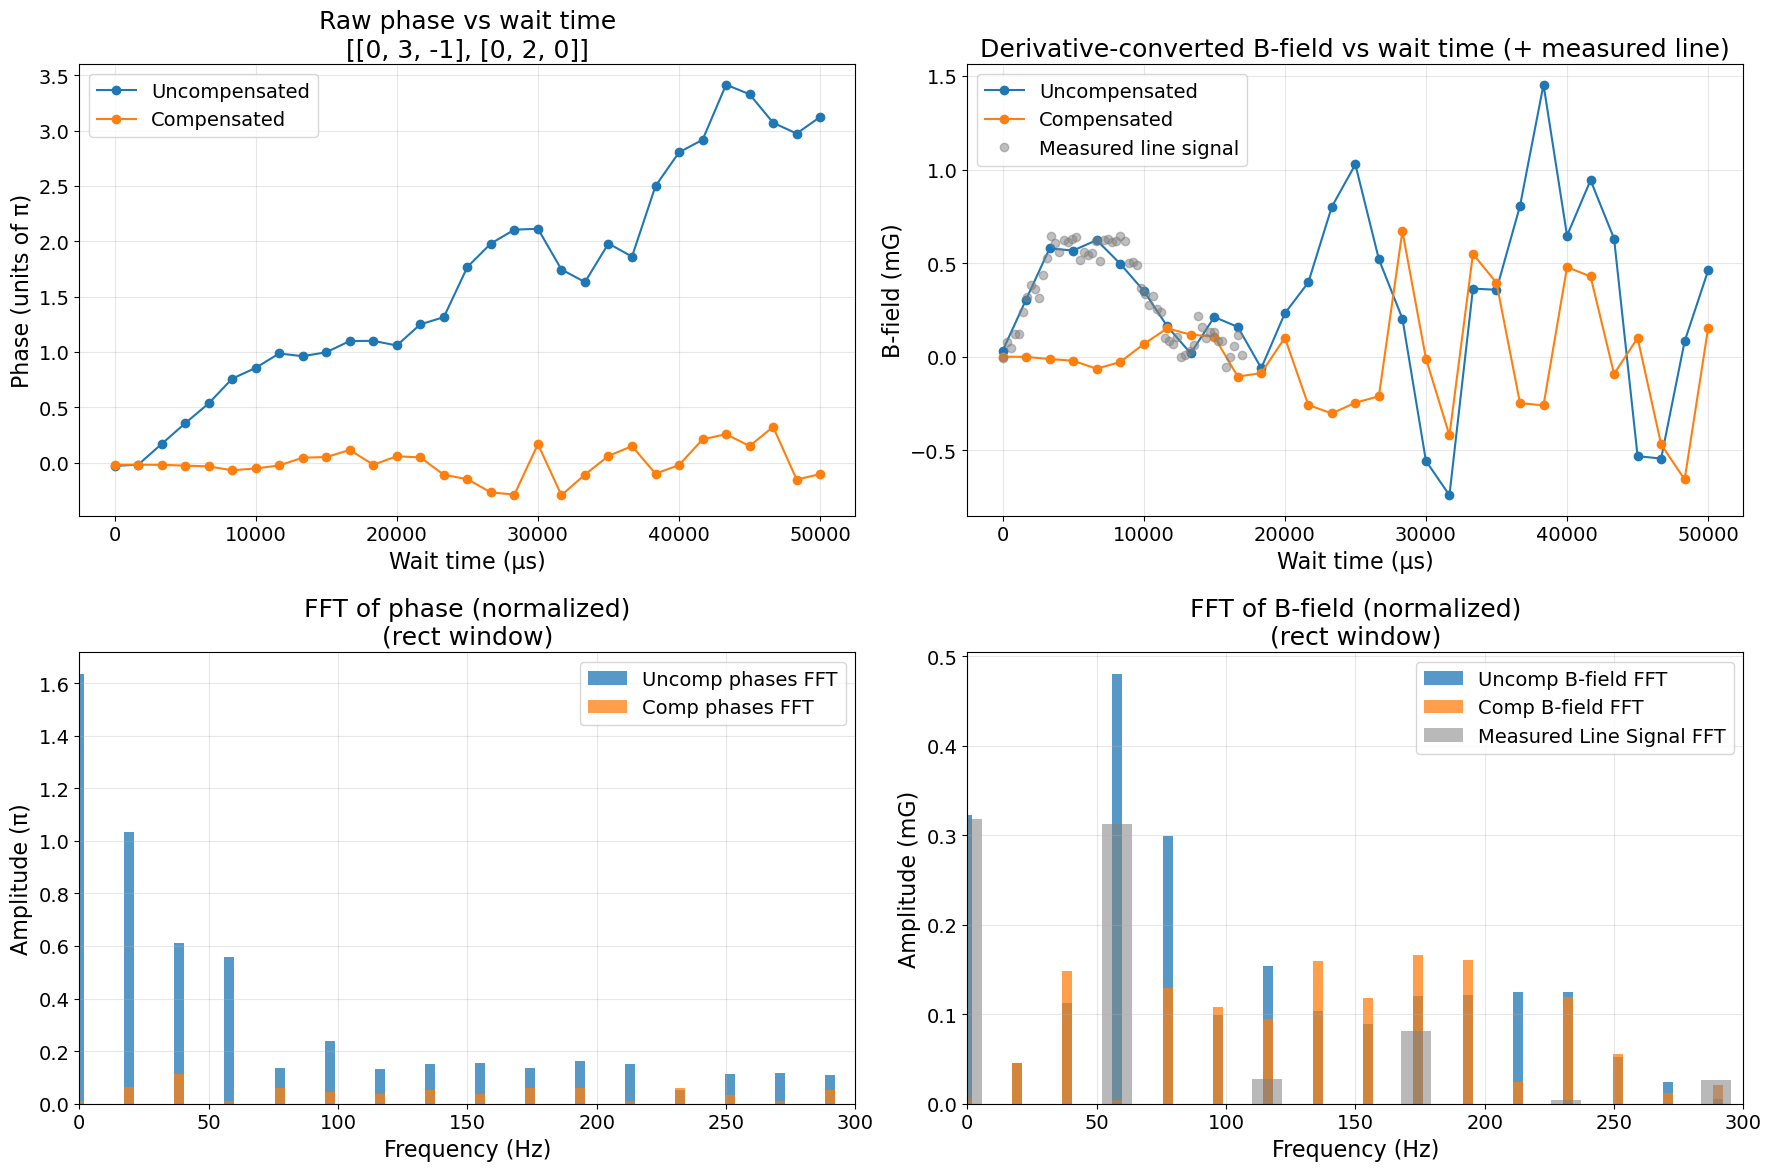

Loaded uncomp: Uncompensated_Phase_Data\((0,_3,_-1),_(0,_2,_0)).txt
Loaded comp  : Compensated_Phase_Data\((0,_3,_-1),_(0,_2,_0)).txt
Uncomp dt (s): 0.0016669999999999983   N: 31
Comp   dt (s): 0.0016669999999999983   N: 31
Line signal file: LineSignal_Data/line_signal_pm_new.json
Line dt (s): 0.0002881355932203393   N: 60
[[0, 3, 0], [0, 2, 0]]
sens_list: [np.float64(1.0365568070938025), np.float64(4.0589839045424014e-05)]


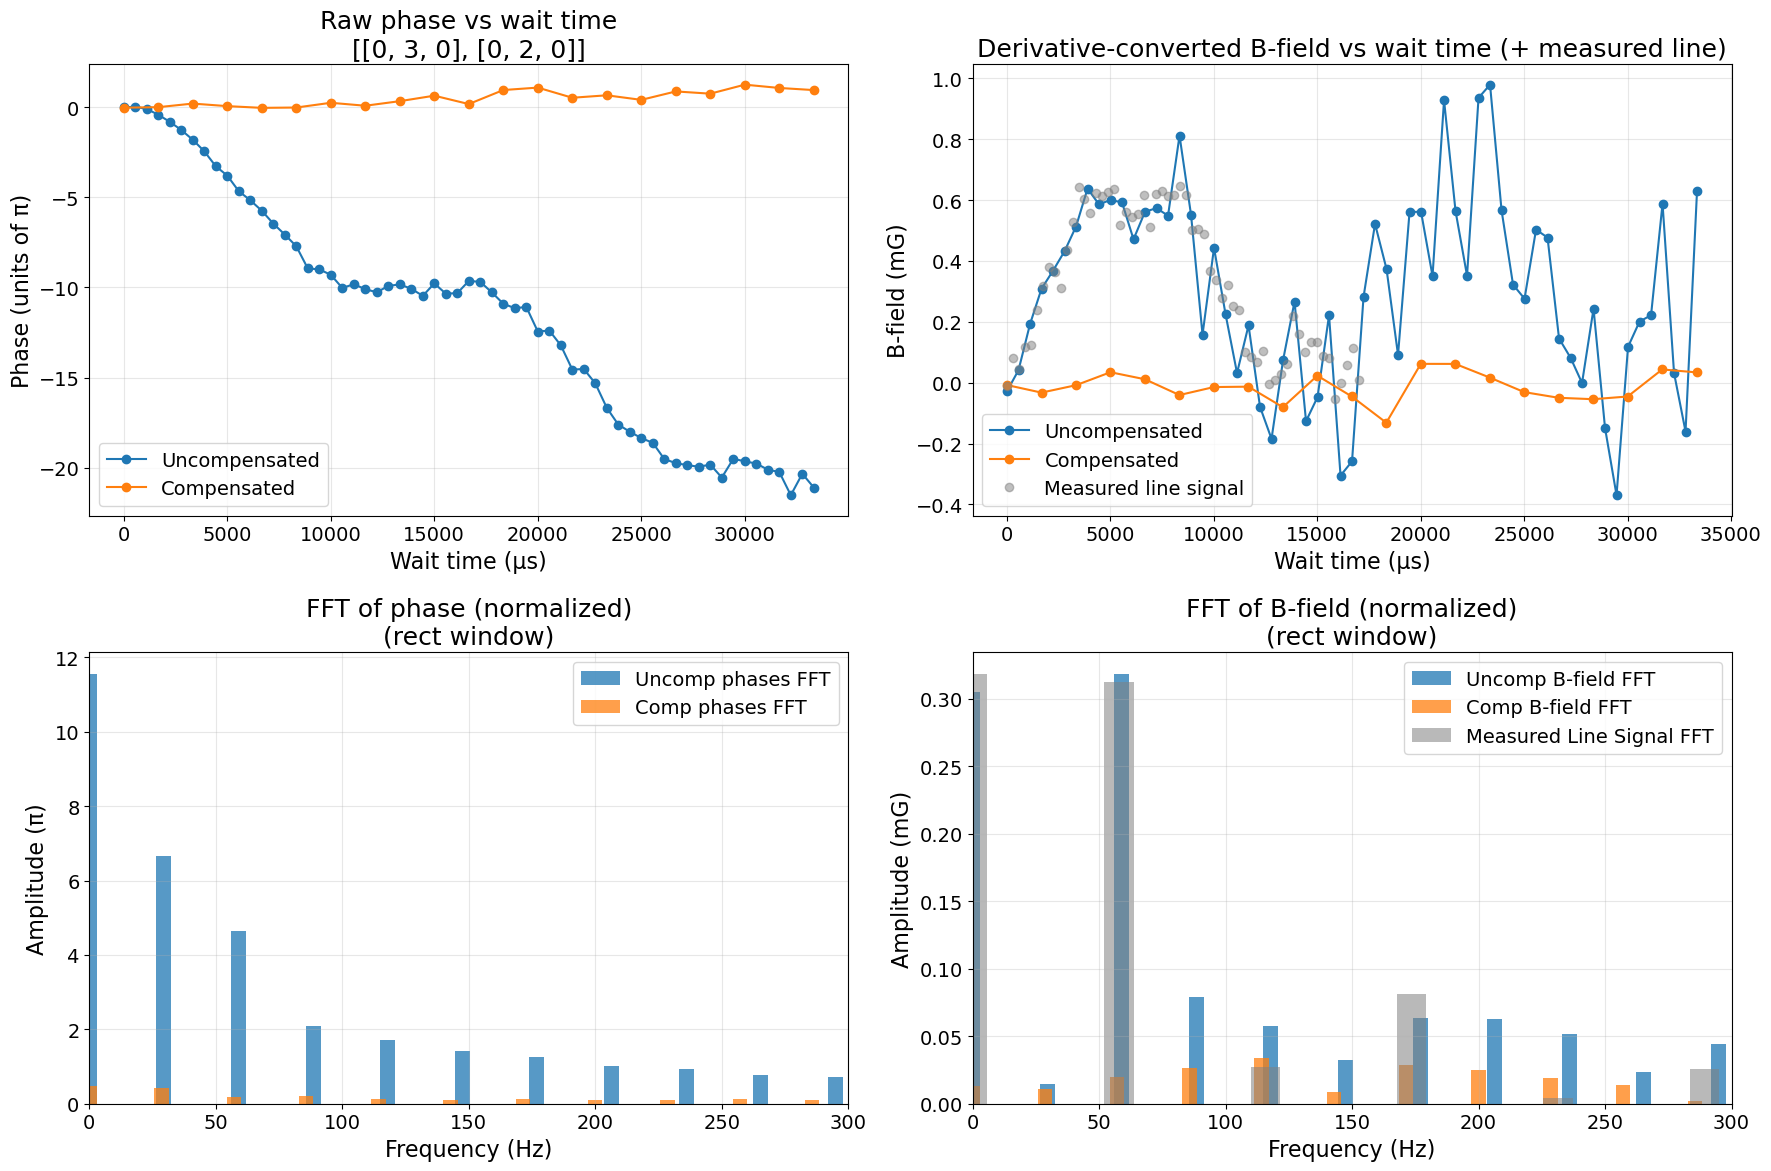

Loaded uncomp: Uncompensated_Phase_Data\((0,_3,_0),_(0,_2,_0)).txt
Loaded comp  : Compensated_Phase_Data\((0,_3,_0),_(0,_2,_0)).txt
Uncomp dt (s): 0.0005559999999999975   N: 61
Comp   dt (s): 0.0016669999999999988   N: 21
Line signal file: LineSignal_Data/line_signal_pm_new.json
Line dt (s): 0.0002881355932203393   N: 60
[[0, 3, 1], [0, 2, 0]]
sens_list: [np.float64(2.1385194393133133), np.float64(4.0589839045424014e-05)]


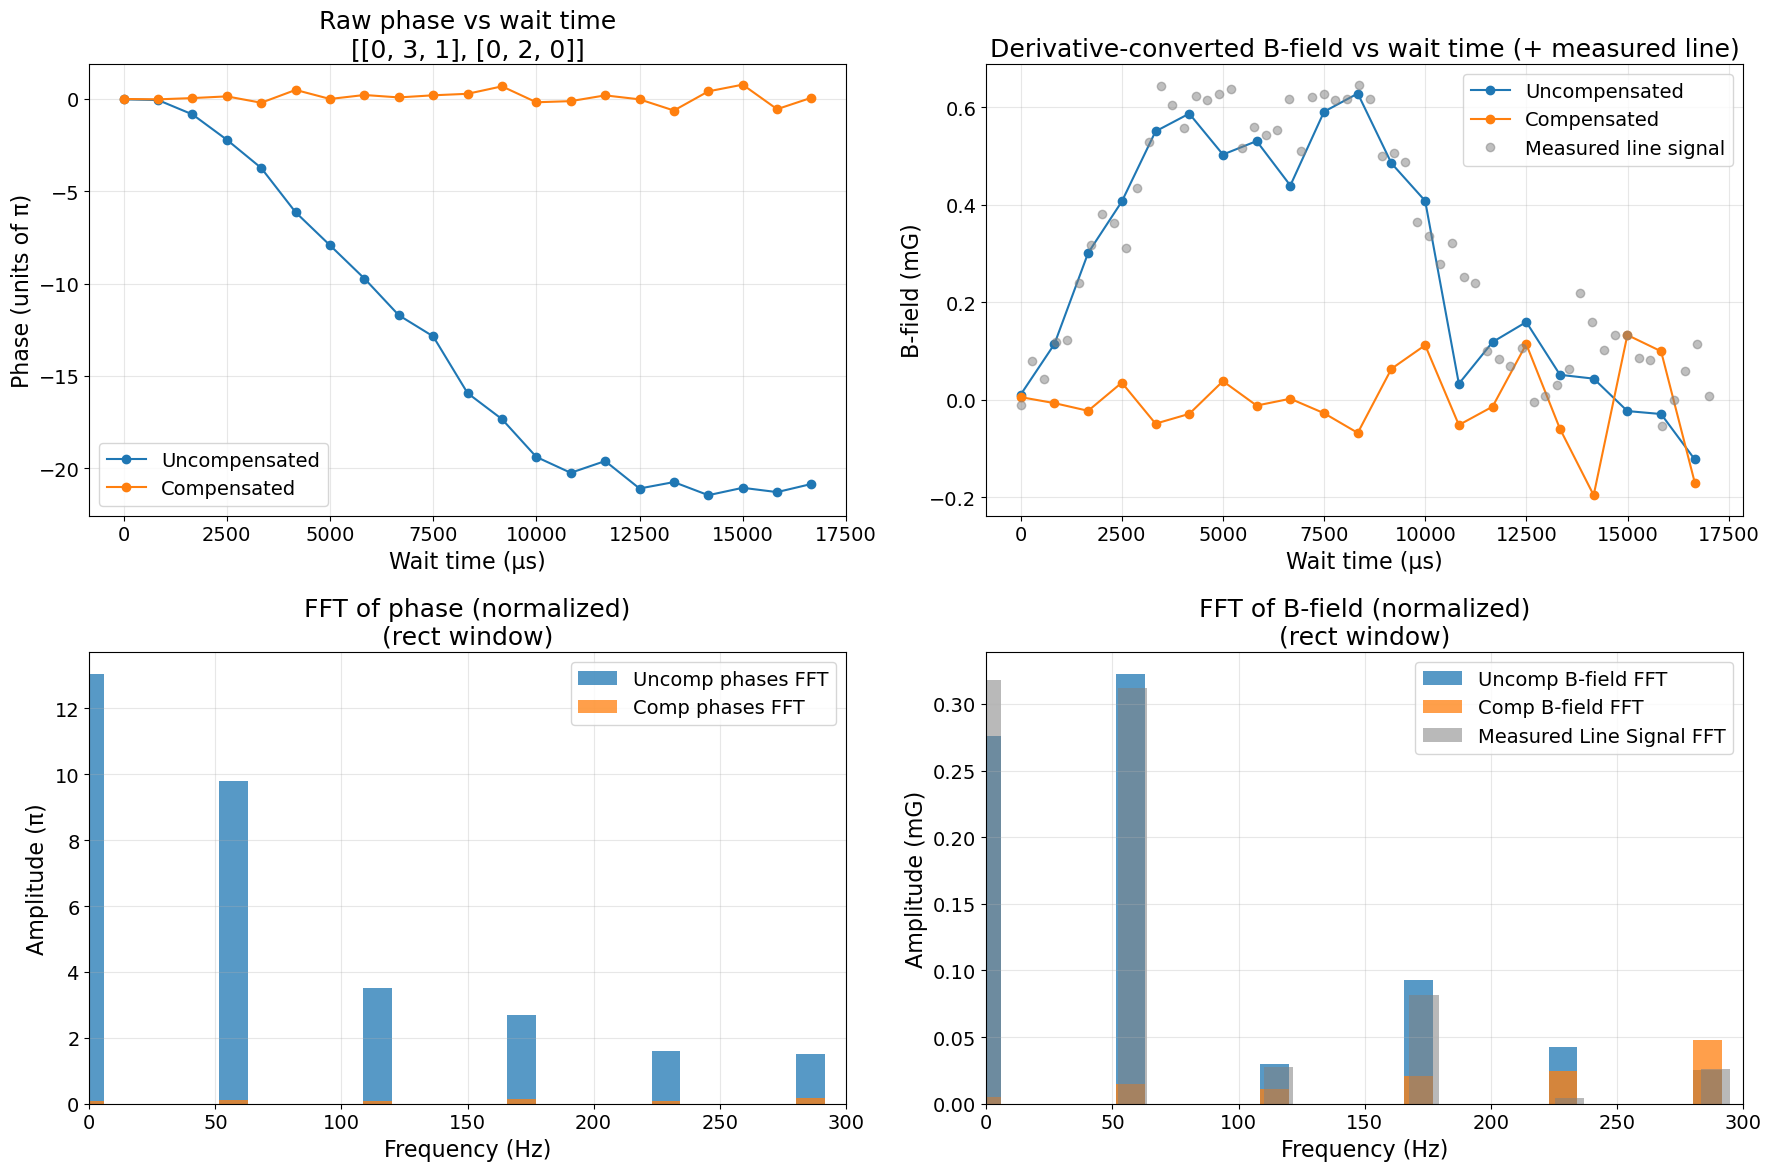

Loaded uncomp: Uncompensated_Phase_Data\((0,_3,_1),_(0,_2,_0)).txt
Loaded comp  : Compensated_Phase_Data\((0,_3,_1),_(0,_2,_0)).txt
Uncomp dt (s): 0.0008330000000000004   N: 21
Comp   dt (s): 0.0008330000000000004   N: 21
Line signal file: LineSignal_Data/line_signal_pm_new.json
Line dt (s): 0.0002881355932203393   N: 60
[[0, 3, 2], [0, 2, 0]]
sens_list: [np.float64(3.201525699978447), np.float64(4.0589839045424014e-05)]


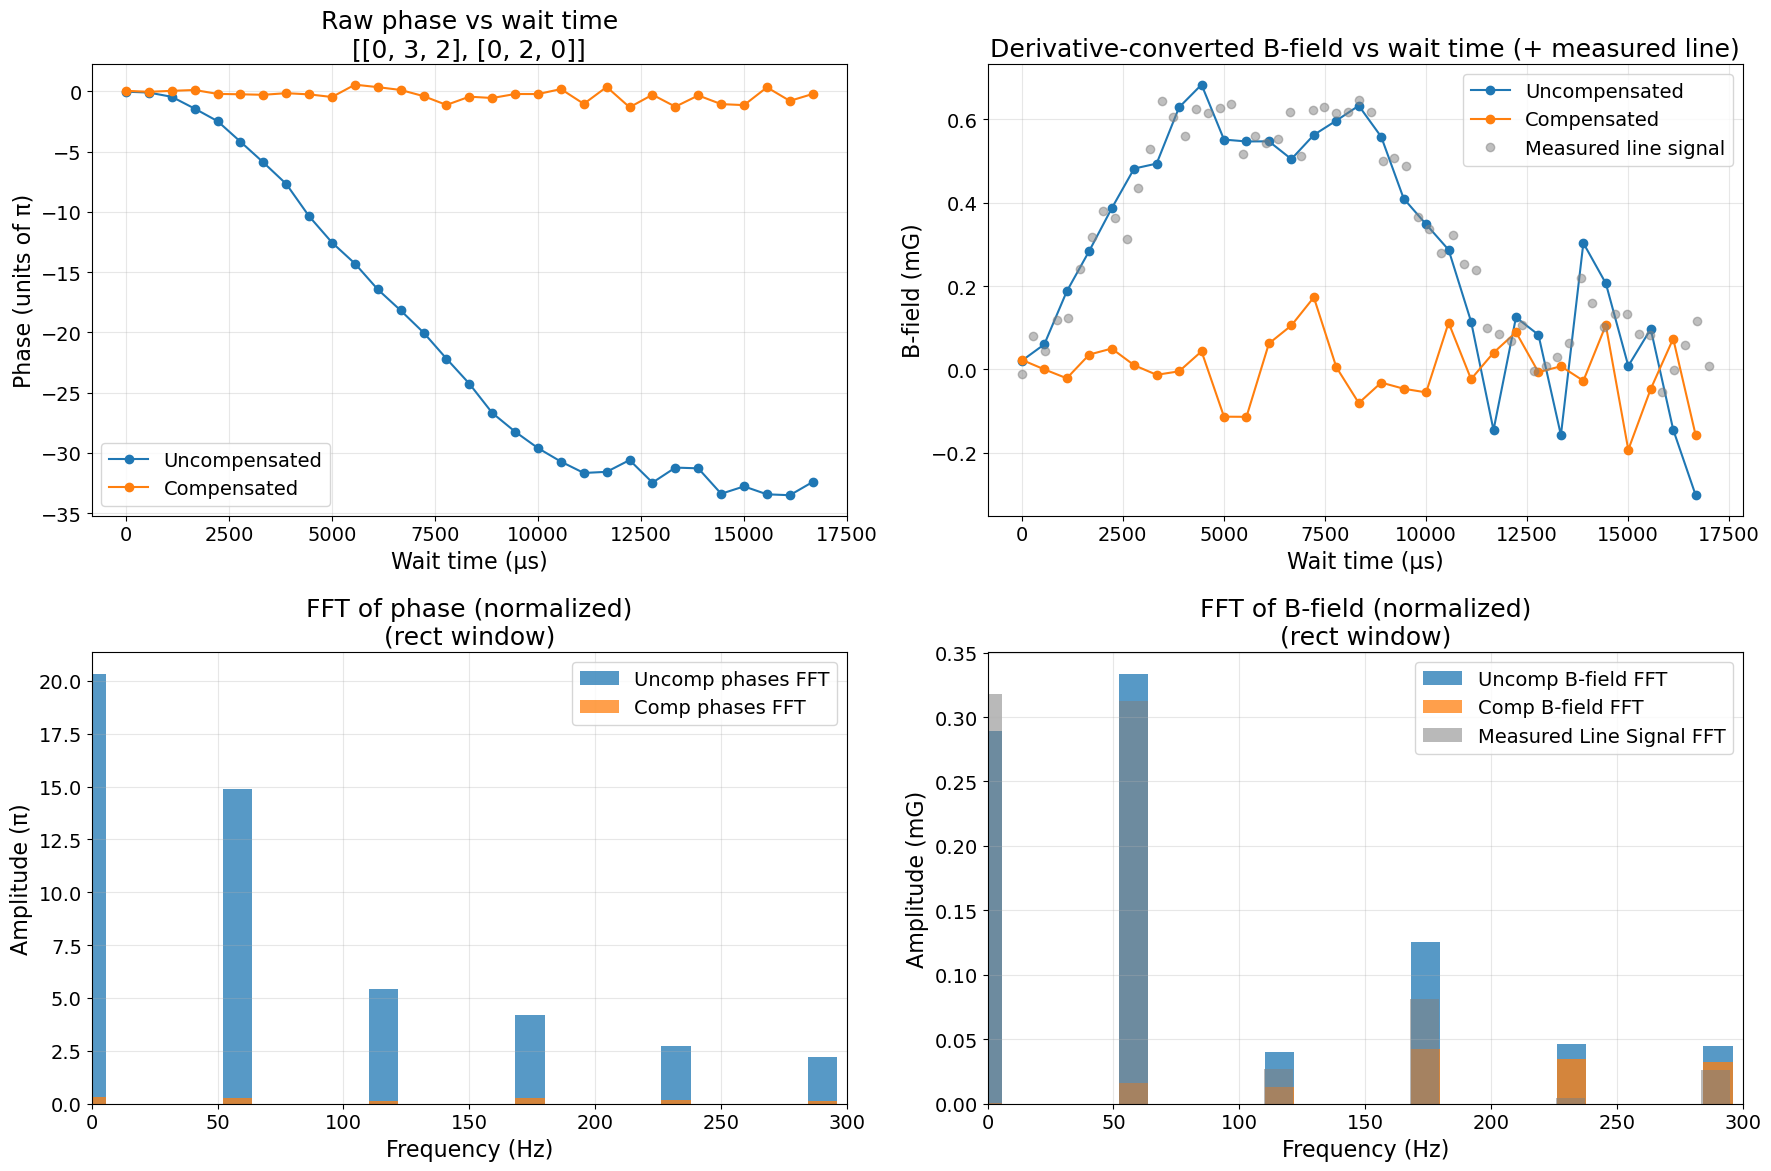

Loaded uncomp: Uncompensated_Phase_Data\((0,_3,_2),_(0,_2,_0)).txt
Loaded comp  : Compensated_Phase_Data\((0,_3,_2),_(0,_2,_0)).txt
Uncomp dt (s): 0.0005559999999999992   N: 31
Comp   dt (s): 0.0005559999999999992   N: 31
Line signal file: LineSignal_Data/line_signal_pm_new.json
Line dt (s): 0.0002881355932203393   N: 60
[[0, 4, -2], [0, 2, 0]]
sens_list: [np.float64(-3.42018057358473), np.float64(4.0589839045424014e-05)]


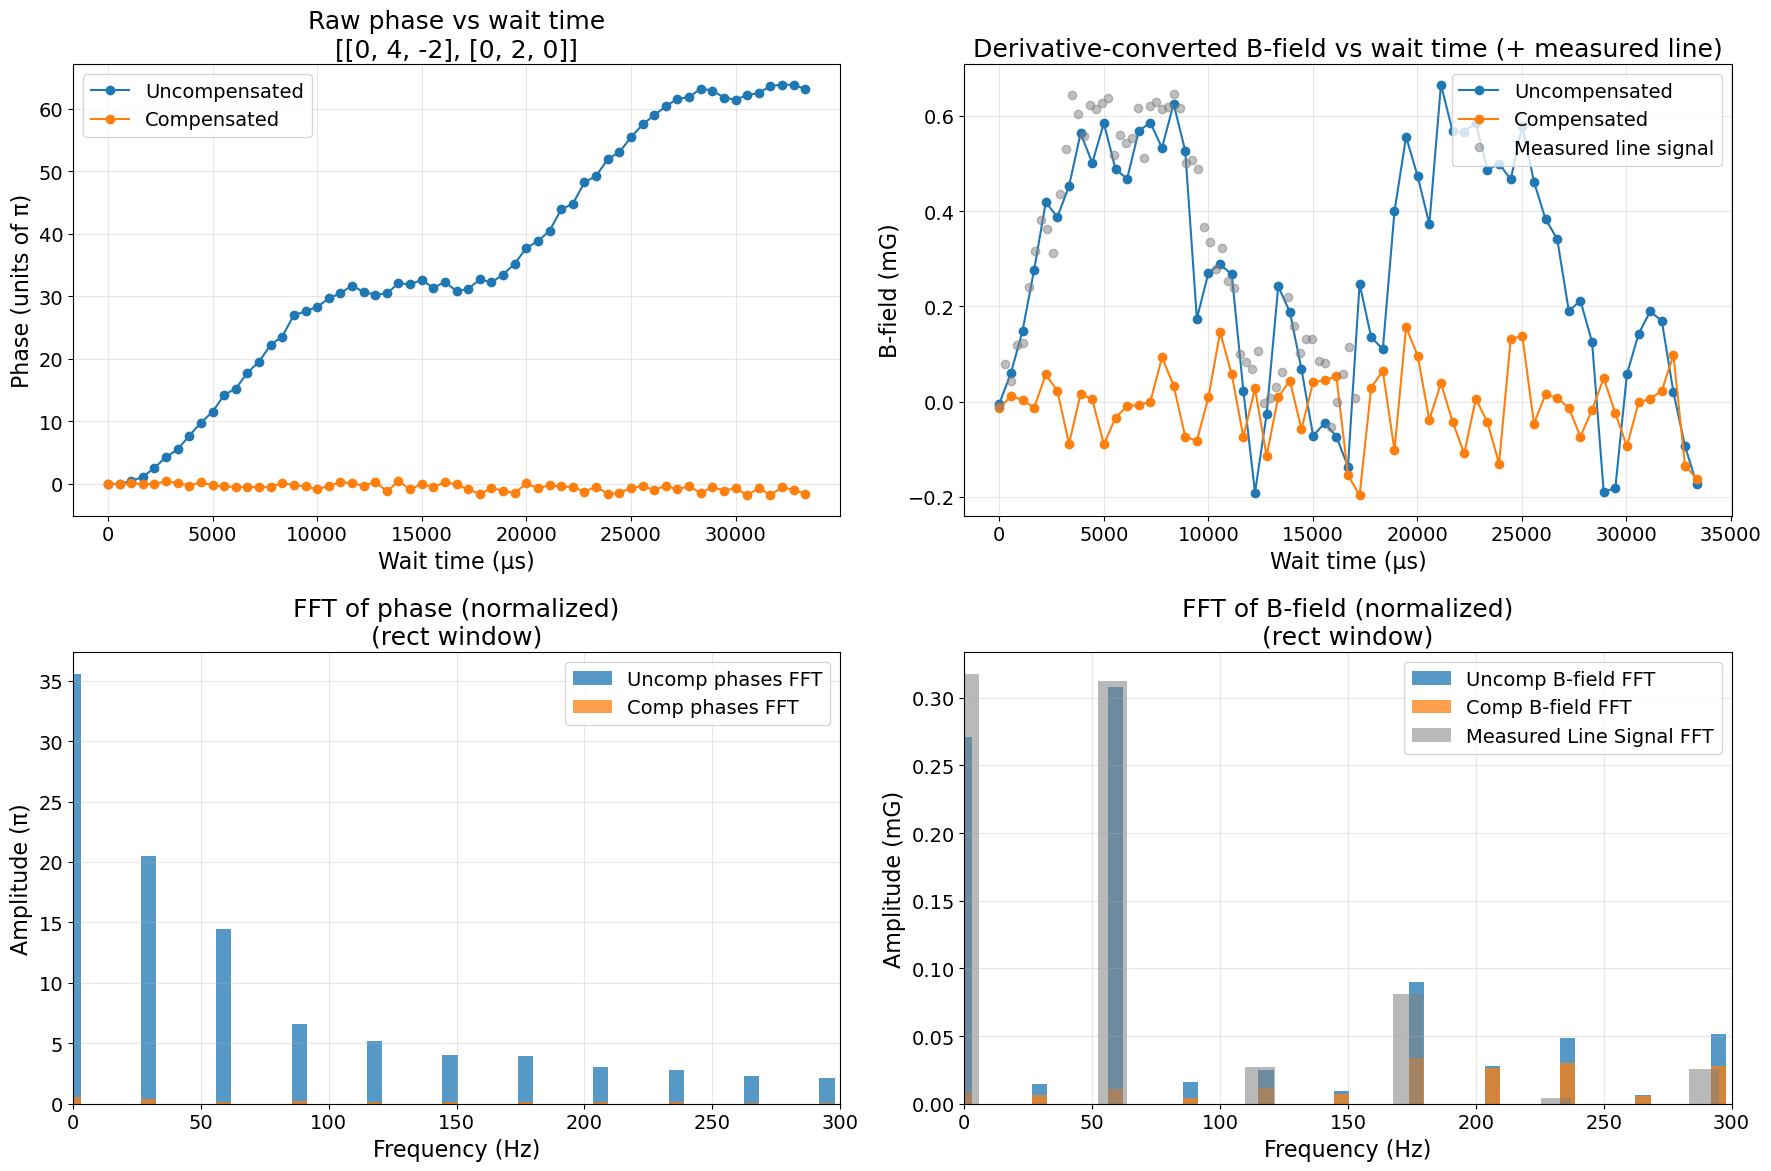

Loaded uncomp: Uncompensated_Phase_Data\((0,_4,_-2),_(0,_2,_0)).txt
Loaded comp  : Compensated_Phase_Data\((0,_4,_-2),_(0,_2,_0)).txt
Uncomp dt (s): 0.0005559999999999975   N: 61
Comp   dt (s): 0.0005559999999999975   N: 61
Line signal file: LineSignal_Data/line_signal_pm_new.json
Line dt (s): 0.0002881355932203393   N: 60
[[0, 4, -1], [0, 2, 0]]
sens_list: [np.float64(-2.4663025196787203), np.float64(4.0589839045424014e-05)]


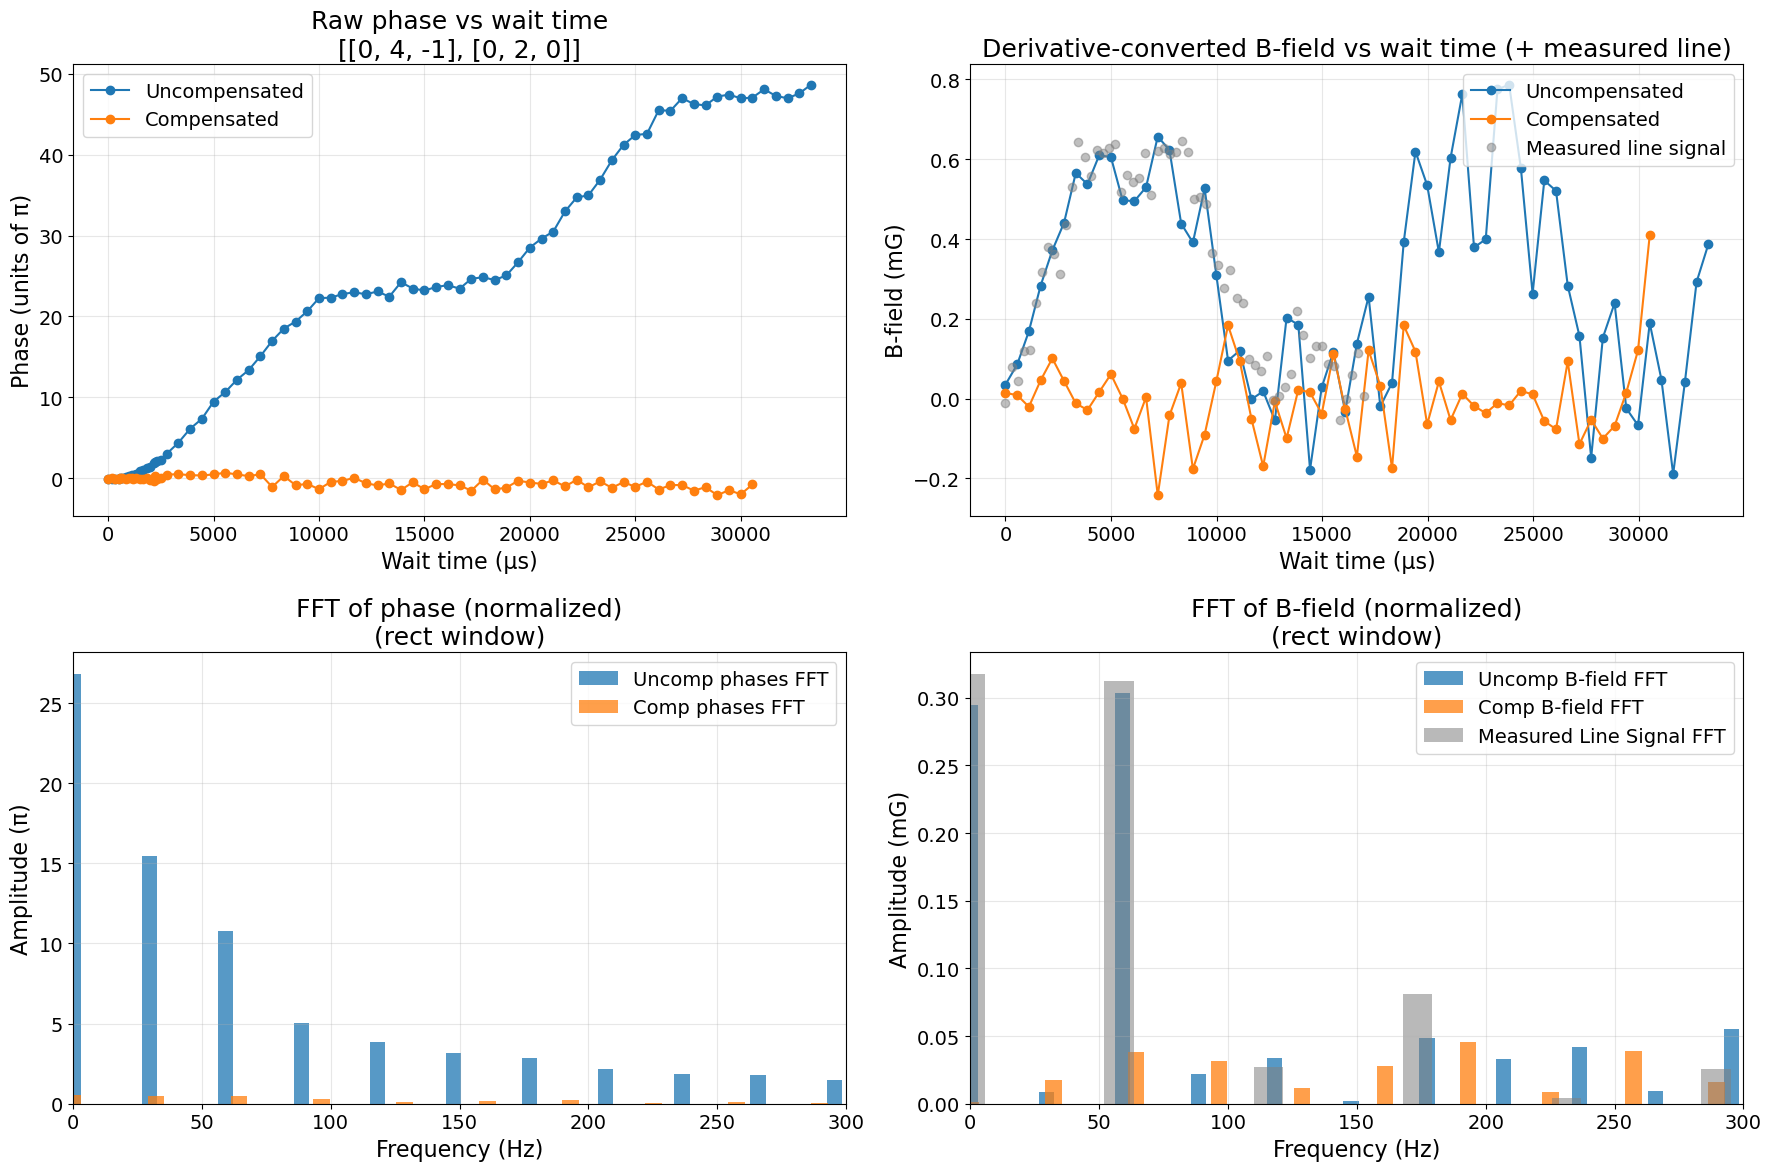

Loaded uncomp: Uncompensated_Phase_Data\((0,_4,_-1),_(0,_2,_0)).txt
Loaded comp  : Compensated_Phase_Data\((0,_4,_-1),_(0,_2,_0)).txt
Uncomp dt (s): 0.0005549999999999999   N: 61
Comp   dt (s): 0.0005549999999999999   N: 56
Line signal file: LineSignal_Data/line_signal_pm_new.json
Line dt (s): 0.0002881355932203393   N: 60
[[0, 4, 0], [0, 2, 0]]
sens_list: [np.float64(-1.3868685343823017), np.float64(4.0589839045424014e-05)]


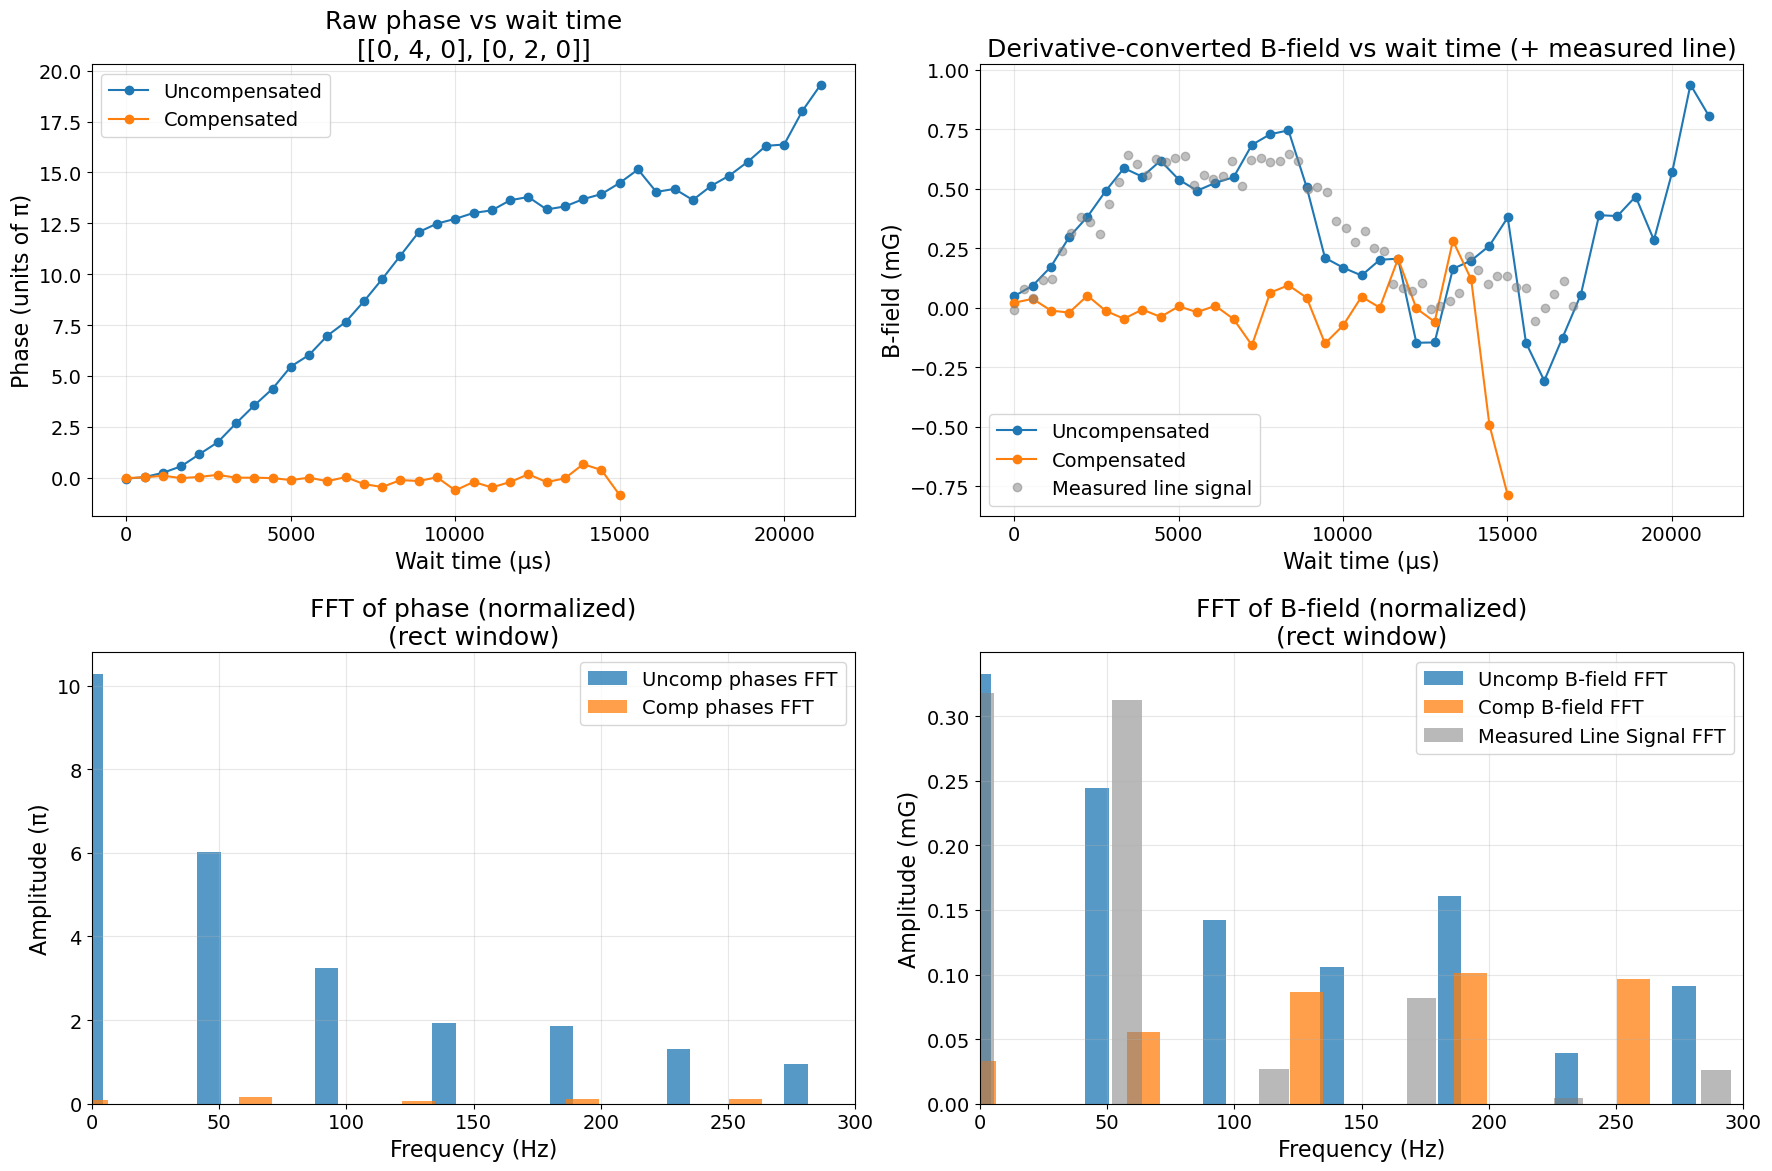

Loaded uncomp: Uncompensated_Phase_Data\((0,_4,_0),_(0,_2,_0)).txt
Loaded comp  : Compensated_Phase_Data\((0,_4,_0),_(0,_2,_0)).txt
Uncomp dt (s): 0.0005559999999999983   N: 39
Comp   dt (s): 0.0005559999999999992   N: 28
Line signal file: LineSignal_Data/line_signal_pm_new.json
Line dt (s): 0.0002881355932203393   N: 60
[[0, 4, 1], [0, 2, 0]]
sens_list: [np.float64(-0.19874388090102002), np.float64(4.0589839045424014e-05)]


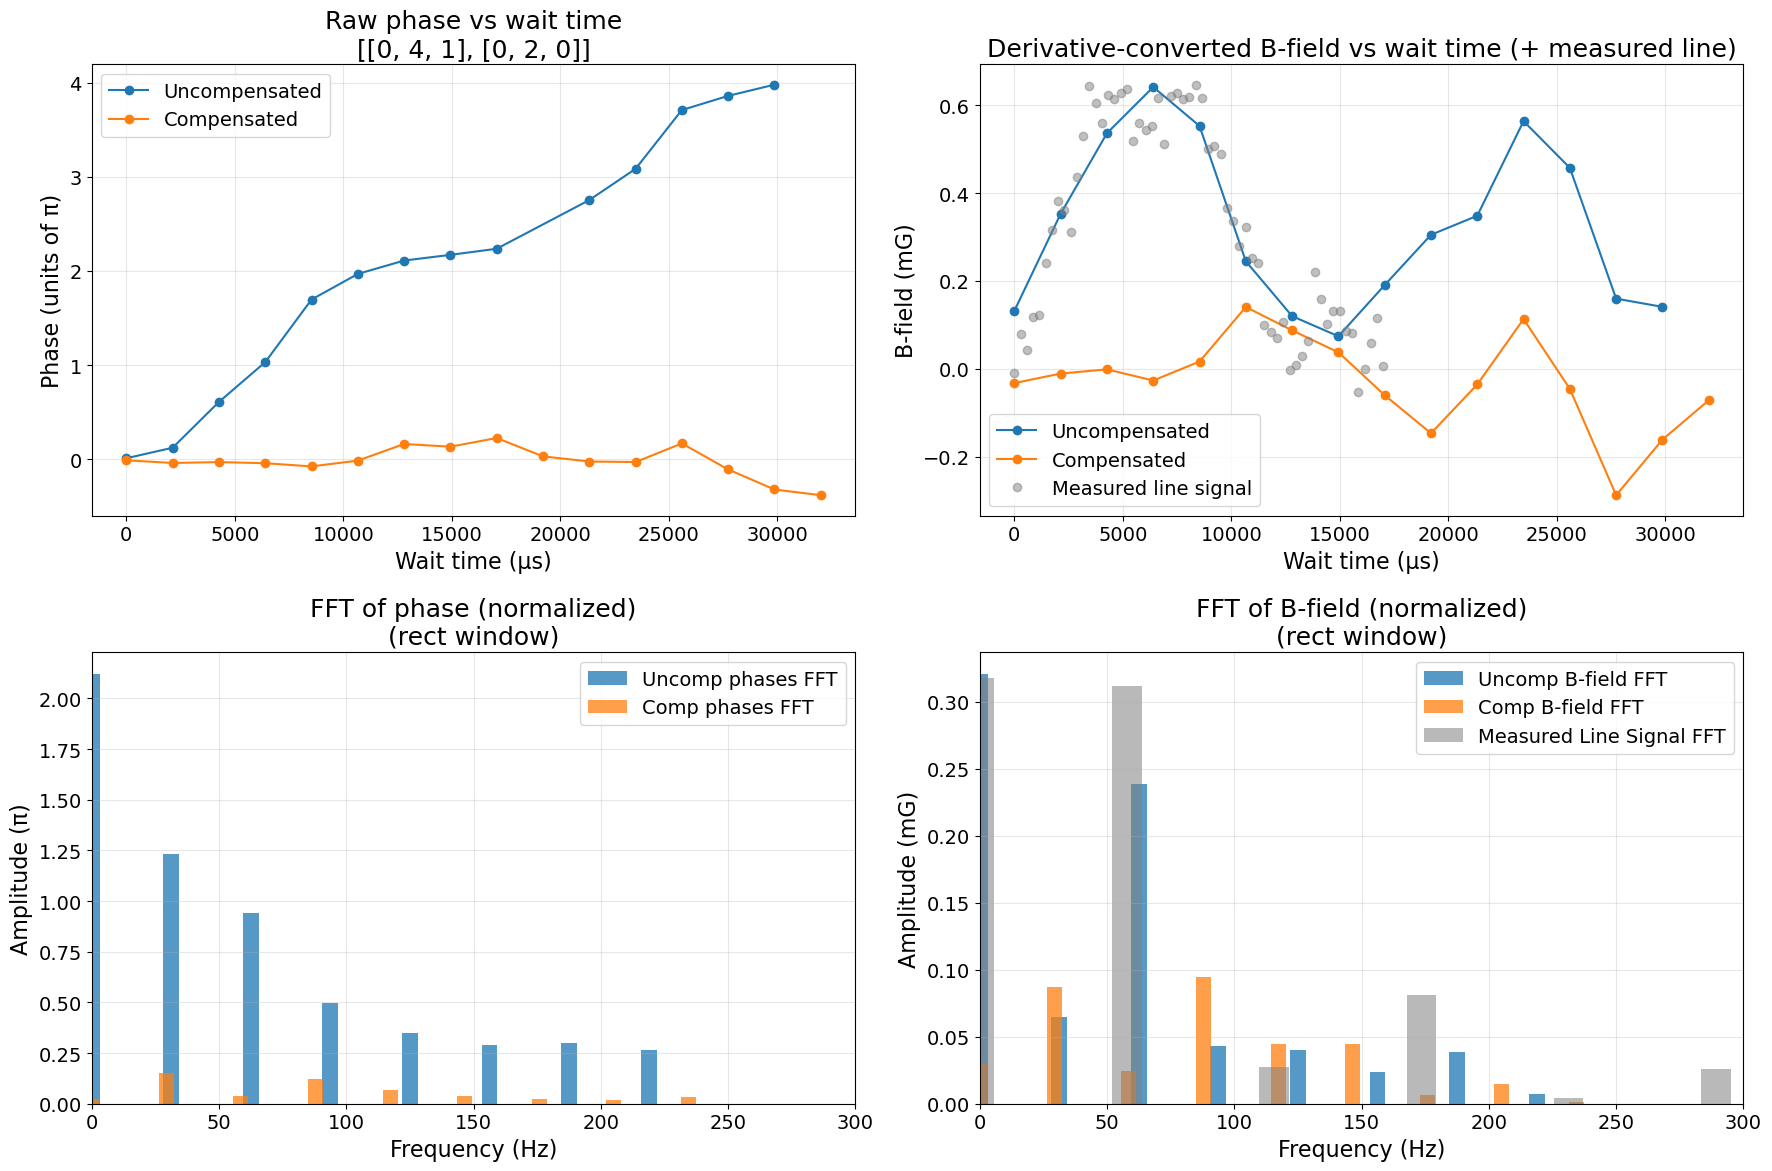

Loaded uncomp: Uncompensated_Phase_Data\((0,_4,_1),_(0,_2,_0)).txt
Loaded comp  : Compensated_Phase_Data\((0,_4,_1),_(0,_2,_0)).txt
Uncomp dt (s): 0.002133000000000001   N: 15
Comp   dt (s): 0.002133   N: 16
Line signal file: LineSignal_Data/line_signal_pm_new.json
Line dt (s): 0.0002881355932203393   N: 60


In [14]:
print("Transitions that have datetimes associated with them:")
for item in unique_list:
    print(item["transition"])

    transition = item["transition"]

    compare_comp_vs_uncomp_2x2(
        transition=transition,
        uncomp_dir="Uncompensated_Phase_Data",
        comp_dir="Compensated_Phase_Data",
        combine_method="mean",
        fmax=300,          # None => no limit
        window=None,       # None => rect
        line_signal_path="LineSignal_Data/line_signal_pm_new.json",  
        line_signal_label="Measured line signal",
        line_signal_combine_method="mean",
    )